In [1]:
library(bigrquery)
library(knitr)
library(tidyverse)
library(ggplot2)
library("table1")
library("IRdisplay")
bq_auth()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘table1’


The following objects are masked from ‘package:base’:

    units, units<-




In [2]:
data <-bq_dataset_query(query="
SELECT *

 FROM `yhcr-prd-phm-bia-core.CB_MYSPACE_RS.selfharm_new`"
                       ,x="yhcr-prd-phm-bia-core.CB_MYSPACE_RS")

selfharm_new <- bq_table_download(data) 

In [3]:
head(selfharm_new)

person_id,birth_datetime,ethnic_group,gender_source_value,dateevent,age_at_encounter,age_band,snomedcode,IMD,LSOA_Name,event_year,row_num
<int>,<dttm>,<chr>,<chr>,<dttm>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>
13280018,1999-08-15,White,Female,2015-06-14 00:00:01,16,16-18,55680006,7,Bradford 004A E01010638,2015,1
13280018,1999-08-15,White,Female,2014-06-02 00:00:01,15,11-15,55680006,7,Bradford 004A E01010638,2014,1
13430837,2002-05-15,White,Female,2017-04-19 10:00:00,15,11-15,248062006,7,Bradford 004A E01010638,2017,1
13059387,2002-12-15,Unknown,Female,2017-06-28 00:00:01,15,11-15,55680006,7,Bradford 004A E01010638,2017,1
13059387,2002-12-15,Unknown,Female,2019-07-11 13:00:01,17,16-18,59274003,7,Bradford 004A E01010638,2019,1
13059387,2002-12-15,Unknown,Female,2017-06-27 00:00:01,15,11-15,55680006,7,Bradford 004A E01010638,2017,1


In [4]:
data1 <-bq_dataset_query(query="
select round(avg(count1),5)

from(

SELECT person_id,count(person_id) count1

 FROM `yhcr-prd-phm-bia-core.CB_MYSPACE_RS.selfharm_new`

 group by person_id)base"
                       ,x="yhcr-prd-phm-bia-core.CB_MYSPACE_RS")

selfharmAVG <- bq_table_download(data1) 

In [5]:
library(forcats)

In [6]:
display_jupyter <- function(x) {
  css <- system.file("table1_defaults_1.0/table1_defaults.css", package="table1")
  css <- paste(readLines(css), collapse="\n")
  x <- htmltools::tagList(htmltools::tags$style(css), htmltools::tags$div(class="Rtable1", x))
  IRdisplay::display_html(as.character(x))
}

In [7]:
selfharm_new$age_band <- factor(selfharm_new$age_band, levels = c("0-5", "6-10", "11-15", "16-18"))

In [8]:
label(selfharm_new$IMD)      <- "IMD"
label(selfharm_new$ethnic_group)      <- "Ethnic Group"
label(selfharm_new$gender_source_value)      <- "Gender"
label(selfharm_new$age_band)      <- c("Age Band")

In [9]:
 x<-table1(~ selfharm_new$IMD + selfharm_new$ethnic_group +selfharm_new$gender_source_value +selfharm_new$age_band |selfharm_new$event_year,data=selfharm_new
          ,justify=c("left", "left", rep("center", 5)),format_number = TRUE
          ,caption = "COS-EY 3: Mental Health Risk:
a demographic breakdown of a Bradford Primary Care sample from Connected Bradford using recommended ONS OpenCodelists Snomed Codes'
Due to the sensitive nature of snomed codes included, we are unable to report specific issues. The below is an aggregation of over 1,000 Snomed Codes relating to mental health"
         )


Warning message in table1.formula(~selfharm_new$IMD + selfharm_new$ethnic_group + :
“Terms to the right of '|' in formula 'x' define table columns and are expected to be factors with meaningful labels.”


In [10]:
display_jupyter(x)

,2012(N=296),2013(N=498),2014(N=637),2015(N=551),2016(N=497),2017(N=519),2018(N=450),2019(N=394),2020(N=309),2021(N=320),2022(N=370),Overall(N=4841)
IMD,,,,,,,,,,,,
Mean (SD),2.87 (2.29),3.11 (2.49),3.27 (2.43),3.43 (2.45),2.95 (2.44),2.85 (2.07),3.08 (2.29),2.96 (2.17),2.85 (2.29),3.12 (2.31),2.94 (2.42),3.06 (2.35)
"Median [Min, Max]","2.00 [1.00, 10.0]","2.00 [1.00, 10.0]","3.00 [1.00, 10.0]","3.00 [1.00, 10.0]","2.00 [1.00, 10.0]","2.00 [1.00, 9.00]","2.00 [1.00, 10.0]","2.00 [1.00, 10.0]","2.00 [1.00, 10.0]","2.00 [1.00, 10.0]","2.00 [1.00, 10.0]","2.00 [1.00, 10.0]"
Ethnic Group,,,,,,,,,,,,
Asian or Asian British,42 (14.2%),87 (17.5%),126 (19.8%),90 (16.3%),90 (18.1%),80 (15.4%),80 (17.8%),72 (18.3%),52 (16.8%),56 (17.5%),63 (17.0%),838 (17.3%)
Black or African or Caribbean or Black British,1 (0.3%),3 (0.6%),5 (0.8%),2 (0.4%),2 (0.4%),9 (1.7%),4 (0.9%),1 (0.3%),3 (1.0%),2 (0.6%),13 (3.5%),45 (0.9%)
Mixed multiple ethnic groups,14 (4.7%),12 (2.4%),18 (2.8%),20 (3.6%),14 (2.8%),18 (3.5%),16 (3.6%),15 (3.8%),6 (1.9%),9 (2.8%),9 (2.4%),151 (3.1%)
Other ethnic group,2 (0.7%),4 (0.8%),3 (0.5%),12 (2.2%),6 (1.2%),3 (0.6%),5 (1.1%),8 (2.0%),5 (1.6%),10 (3.1%),5 (1.4%),63 (1.3%)
Unknown,56 (18.9%),65 (13.1%),81 (12.7%),87 (15.8%),80 (16.1%),78 (15.0%),57 (12.7%),61 (15.5%),46 (14.9%),34 (10.6%),47 (12.7%),692 (14.3%)
White,181 (61.1%),327 (65.7%),404 (63.4%),340 (61.7%),305 (61.4%),331 (63.8%),288 (64.0%),237 (60.2%),197 (63.8%),209 (65.3%),233 (63.0%),3052 (63.0%)


In [22]:
#selfharm_percentage<- 
selfharm_percentage %>%
    mutate(output=ifelse(percentage <10,ifelse(percentage>10 ,0,NA),percentage))

event_year,percentage,output
<fct>,<dbl>,<dbl>
2012,6.114439,NA
2013,10.287131,10.28713
2014,13.158438,13.15844
2015,11.381946,11.38195
2016,10.266474,10.26647
2017,10.720925,10.72093
2018,9.295600,NA
2019,8.138814,NA
2020,6.382979,NA


In [34]:

selfharm_percentage <- selfharm_new %>%
  group_by(event_year) %>%
  summarise(percentage = n() / nrow(selfharm_new) * 100)


selfharm_percentage$event_year <- factor(selfharm_percentage$event_year, levels = as.character(2012:2023))

selfharm_percentage<- selfharm_percentage %>%
    mutate(output=ifelse(percentage <10,ifelse(percentage>10 ,0,NA),percentage))

OVERALL<- 
ggplot(selfharm_percentage, aes(x = event_year, y = output, group = 1, )) +
  geom_line() +
  geom_point() +
   labs(caption = "small numbers removed")+
  labs(title = "COS-EY 3: Mental Health Risk Percentage Over Time",
       x = "Event Year",
       y = "Percentage") +

scale_y_continuous(labels = function(x) paste0(x, "%"))+
               theme(panel.border = element_blank(),# panel.grid.major = element_blank(),
#panel.grid.minor = element_blank(), 
      axis.line = element_line(colour = "black"),axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+
geom_text(aes(label = round(output,0)), hjust = 0.75,  vjust = -1) +
                   theme_minimal()+
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))+
  theme_minimal()

In [35]:
library(grid)
#library(gridtext)
library(gridExtra)

pdf('COS-EY 3: Mental Health Risk Percentage Over Time.pdf',width=10, height=10)
  title <- "COS-EY 3: Mental Health Risk Percentage Over Time"
grid.text(title) 
OVERALL
dev.off()

Warning message:
“Removed 6 rows containing missing values (`geom_line()`).”
Warning message:
“Removed 6 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 6 rows containing missing values (`geom_text()`).”


png 
  2

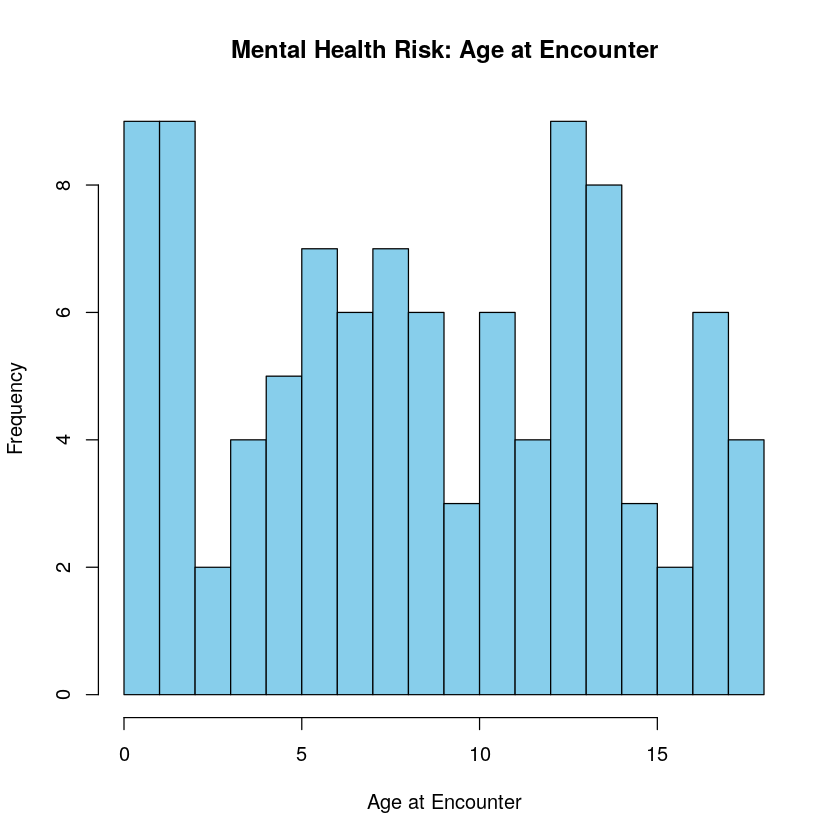

In [13]:
selfharm_new <- data.frame(age_at_encounter = sample(1:18, 100, replace = TRUE))


hist(selfharm_new$age_at_encounter, 
     col = "skyblue",             # Specify color
     main = "Mental Health Risk: Age at Encounter",   # Title of the plot
     xlab = "Age at Encounter",   # X-axis label
     ylab = "Frequency",          # Y-axis label
     breaks = seq(0, max(selfharm_new$age_at_encounter), by = 1))  # Specify breaks